In [1]:
# Import des bibliothèques nécessaires
import pandas as pd
import numpy as np

In [2]:
# Palette et style graphique cohérents pour l'ensemble du notebook
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

PALETTE = {
    'surface': '#fcfcfb',
    'ink': '#0b0b0b',
    'ink_secondary': '#52514e',
    'ink_muted': '#898781',
    'grid': '#e1e0d9',
    'axis': '#c3c2b7',
    'blue': '#2a78d6',
    'orange': '#eb6834',
    'aqua': '#1baf7a',
    'yellow': '#eda100',
    'magenta': '#e87ba4',
    'green': '#008300',
    'violet': '#4a3aa7',
    'red': '#e34948',
    'good': '#0ca30c',
    'critical': '#d03b3b',
}
CATEGORICAL = [PALETTE[c] for c in ['blue', 'orange', 'aqua', 'yellow', 'magenta', 'green', 'violet', 'red']]

plt.rcParams.update({
    'figure.facecolor': PALETTE['surface'],
    'axes.facecolor': PALETTE['surface'],
    'axes.edgecolor': PALETTE['axis'],
    'axes.labelcolor': PALETTE['ink_secondary'],
    'axes.titlecolor': PALETTE['ink'],
    'axes.axisbelow': True,
    'axes.spines.top': False,
    'axes.spines.right': False,
    'grid.color': PALETTE['grid'],
    'grid.linewidth': 0.8,
    'grid.linestyle': '-',
    'xtick.color': PALETTE['ink_muted'],
    'ytick.color': PALETTE['ink_muted'],
    'text.color': PALETTE['ink'],
    'font.size': 11,
    'legend.frameon': False,
})


def style_axes(ax, grid_axis='x'):
    """Finitions communes : grille discrète en fond, pas de cadre superflu, ticks fins."""
    ax.grid(axis=grid_axis, color=PALETTE['grid'], linewidth=0.8, zorder=0)
    ax.set_axisbelow(True)
    for spine in ('top', 'right'):
        ax.spines[spine].set_visible(False)
    ax.tick_params(length=0)

In [3]:
# Récupération de la liste des 62 fichiers de données situés dans "Data/dataverse_files/"
import glob
filenames = glob.glob("Data/dataverse_files/*.txt")

In [4]:
# Noms des colonnes du fichier (le fichier ne contient pas d'en-tête)
col_list = ['gridID', 'timeInterval', 'countryCode', 'smsIn', 'smsOut', 'callIn', 'callOut', 'internet']

# Colonnes réellement utiles (on exclut countryCode pour accélérer la lecture)
cols_to_use = ['gridID', 'timeInterval', 'smsIn', 'smsOut', 'callIn', 'callOut', 'internet']

# Types optimisés (float32/int32 au lieu de float64/int64) pour réduire la mémoire et accélérer la lecture
dtypes = {
    'gridID': 'int32',
    'smsIn': 'float32',
    'smsOut': 'float32',
    'callIn': 'float32',
    'callOut': 'float32',
    'internet': 'float32'
}

## Compréhension et qualité du dataset brut

Avant de lancer le traitement complet des 62 fichiers (long), on charge un seul fichier (une journée) pour comprendre la structure des données : nombre d'observations, signification des colonnes, valeurs manquantes et statistiques descriptives.

In [5]:
# Chargement d'un seul fichier (une journée) pour explorer la structure des données brutes
sample_data = pd.read_csv(filenames[0], sep='\t', header=None, names=col_list)
sample_data.shape

(4842625, 8)

In [6]:
# Aperçu des 10 premières lignes du fichier brut
sample_data.head(10)

,gridID,timeInterval,countryCode,smsIn,smsOut,callIn,callOut,internet
0,1,1383260400000,0,0.081363,NaN,NaN,NaN,NaN
1,1,1383260400000,39,0.141864,0.156787,0.160938,0.052275,11.028366
2,1,1383261000000,0,0.136588,NaN,NaN,0.027300,NaN
3,1,1383261000000,33,NaN,NaN,NaN,NaN,0.026137
4,1,1383261000000,39,0.278452,0.119926,0.188777,0.133637,11.100963
5,1,1383261600000,0,0.053438,NaN,NaN,NaN,NaN
6,1,1383261600000,39,0.330641,0.170952,0.134176,0.054601,10.892771
7,1,1383262200000,0,0.026137,NaN,NaN,NaN,NaN
8,1,1383262200000,39,0.681434,0.220815,0.027300,0.053438,8.622425
9,1,1383262800000,0,0.027300,NaN,NaN,NaN,NaN


In [7]:
# Types de données de chaque colonne
sample_data.dtypes

gridID            int64
timeInterval      int64
countryCode       int64
smsIn           float64
smsOut          float64
callIn          float64
callOut         float64
internet        float64
dtype: object

### Signification des colonnes

| Colonne | Signification |
|---|---|
| gridID | Identifiant de la cellule géographique (grid), parmi les 10 000 zones carrées de Milan |
| timeInterval | Début de l'intervalle de 10 minutes, en millisecondes depuis epoch (Unix timestamp) |
| countryCode | Indicatif téléphonique du pays d'origine/destination de la communication (0 = trafic domestique italien la plupart du temps) |
| smsIn | Volume de SMS reçus durant l'intervalle |
| smsOut | Volume de SMS envoyés durant l'intervalle |
| callIn | Volume d'appels reçus durant l'intervalle |
| callOut | Volume d'appels émis durant l'intervalle |
| internet | Nombre de CDR (Call Detail Records) générés par le trafic Internet mobile durant l'intervalle |

Chaque ligne ne représente pas forcément une observation complète : une ligne peut ne renseigner qu'un seul type d'activité (par exemple uniquement `smsIn`) pour un triplet `(gridID, timeInterval, countryCode)` donné, les autres colonnes étant alors `NaN`.

In [8]:
# Nombre d'observations et cardinalités clés pour cette journée
print(f"Nombre de lignes (observations) pour cette journée : {len(sample_data)}")
print(f"Nombre de grids uniques : {sample_data['gridID'].nunique()}")
print(f"Nombre de codes pays uniques : {sample_data['countryCode'].nunique()}")
print(f"Nombre d'intervalles de temps uniques : {sample_data['timeInterval'].nunique()}")

Nombre de lignes (observations) pour cette journée : 4842625
Nombre de grids uniques : 10000
Nombre de codes pays uniques : 246
Nombre d'intervalles de temps uniques : 144


On retrouve bien environ 144 intervalles de 10 minutes sur une journée (24h × 6), et jusqu'à 10 000 grids possibles (cohérent avec `milano-grid.geojson`). Le nombre de codes pays uniques donne une idée de la diversité des communications internationales présentes dans les données.

In [9]:
# Valeurs manquantes par colonne (nombre et pourcentage)
missing = pd.DataFrame({
    'valeurs_manquantes': sample_data.isna().sum(),
    'pourcentage_manquant (%)': (sample_data.isna().mean() * 100).round(2)
})
missing

,valeurs_manquantes,pourcentage_manquant (%)
gridID,0,0.00
timeInterval,0,0.00
countryCode,0,0.00
smsIn,1981177,40.91
smsOut,3210070,66.29
callIn,3329423,68.75
callOut,2611016,53.92
internet,2488626,51.39


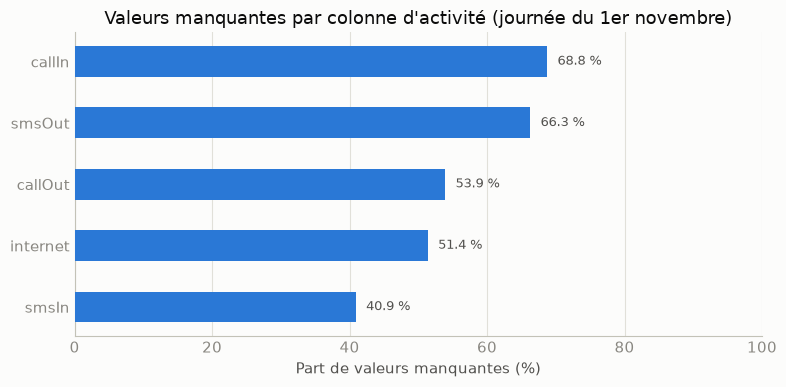

In [10]:
# Version graphique du tableau ci-dessus : plus rapide à lire qu'une colonne de pourcentages
missing_activity = missing.loc[
    ['smsIn', 'smsOut', 'callIn', 'callOut', 'internet'], 'pourcentage_manquant (%)'
].sort_values()

fig, ax = plt.subplots(figsize=(8, 4))
bars = ax.barh(missing_activity.index, missing_activity.values, color=PALETTE['blue'], height=0.5, zorder=3)
for bar, value in zip(bars, missing_activity.values):
    ax.text(bar.get_width() + 1.5, bar.get_y() + bar.get_height() / 2, f"{value:.1f} %",
            va='center', ha='left', color=PALETTE['ink_secondary'], fontsize=9)

ax.set_xlim(0, 100)
ax.set_xlabel("Part de valeurs manquantes (%)")
ax.set_title("Valeurs manquantes par colonne d'activité (journée du 1er novembre)")
style_axes(ax)
plt.tight_layout()
plt.show()

Les colonnes d'activité (`smsIn`, `smsOut`, `callIn`, `callOut`, `internet`) présentent un fort taux de valeurs manquantes. **Ce n'est pas un problème de qualité des données** : chaque ligne du fichier brut correspond à une combinaison `(gridID, timeInterval, countryCode)` et ne renseigne que les types d'activité réellement observés durant cet intervalle — les autres colonnes restent `NaN` faute d'activité de ce type pour cette combinaison précise.

C'est pour cela que l'agrégation utilisée plus loin repose sur `.sum()`, qui ignore les `NaN` par défaut (`skipna=True`) et les traite comme une absence d'activité (0), sans perte d'information.

In [11]:
# Statistiques descriptives des colonnes d'activité
sample_data[['smsIn', 'smsOut', 'callIn', 'callOut', 'internet']].describe()

,smsIn,smsOut,callIn,callOut,internet
count,2.861448e+06,1.632555e+06,1.513202e+06,2.231609e+06,2.353999e+06
mean,1.609810e+00,1.728842e+00,1.733278e+00,1.432492e+00,3.503793e+01
std,3.428510e+00,3.851733e+00,3.612213e+00,3.501098e+00,7.870483e+01
min,2.331498e-06,2.331498e-06,2.331498e-06,2.331498e-06,2.331498e-06
25%,1.400411e-01,1.516063e-01,1.272105e-01,7.685247e-02,1.207738e-01
50%,5.049530e-01,5.339903e-01,4.951206e-01,2.959635e-01,7.793326e+00
75%,1.623971e+00,1.698086e+00,1.747475e+00,1.191590e+00,3.633312e+01
max,2.340182e+02,2.957258e+02,1.909894e+02,1.878688e+02,4.995605e+03


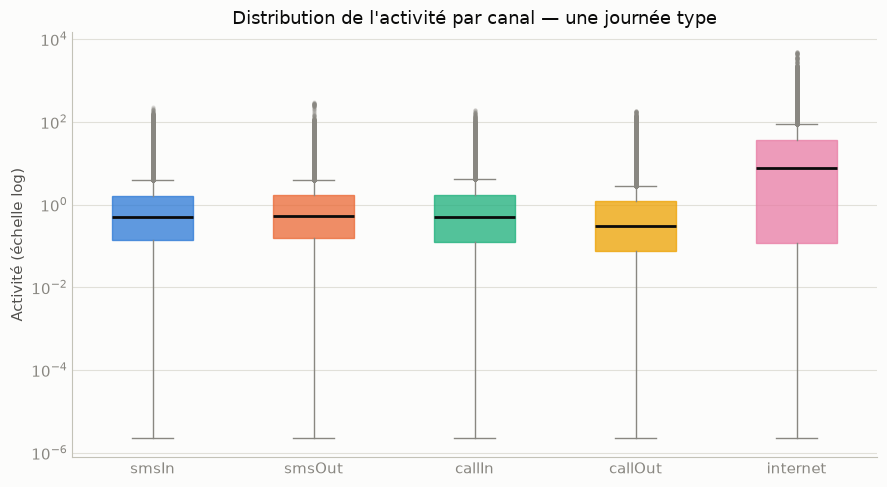

In [12]:
# Version graphique des statistiques ci-dessus : la dissymétrie (moyenne << max) se voit d'un coup d'œil
activity_cols = ['smsIn', 'smsOut', 'callIn', 'callOut', 'internet']
box_data = [sample_data[c].dropna() for c in activity_cols]

fig, ax = plt.subplots(figsize=(9, 5))
bp = ax.boxplot(
    box_data, patch_artist=True, widths=0.5,
    medianprops=dict(color=PALETTE['ink'], linewidth=2),
    whiskerprops=dict(color=PALETTE['ink_muted']),
    capprops=dict(color=PALETTE['ink_muted']),
    flierprops=dict(marker='o', markersize=3, markerfacecolor=PALETTE['ink_muted'],
                     markeredgecolor='none', alpha=0.25),
)
for patch, color in zip(bp['boxes'], CATEGORICAL[:len(activity_cols)]):
    patch.set_facecolor(color)
    patch.set_edgecolor(color)
    patch.set_alpha(0.75)

ax.set_yscale('log')
ax.set_xticks(range(1, len(activity_cols) + 1))
ax.set_xticklabels(activity_cols)
ax.set_ylabel("Activité (échelle log)")
ax.set_title("Distribution de l'activité par canal — une journée type")
style_axes(ax, grid_axis='y')
plt.tight_layout()
plt.show()

Quelques points notables :

- Les valeurs sont continues et souvent inférieures à 1, et non des comptages entiers bruts comme pourrait le laisser penser la documentation (`Description_data.md`) — il s'agit très probablement de valeurs anonymisées/normalisées propres au Telecom Italia Big Data Challenge, proportionnelles à l'activité réelle plutôt que des comptages exacts (10 SMS, 5 appels, etc.). À garder en tête pour l'interprétation des résultats.
- L'écart important entre la moyenne et le maximum indique une distribution très asymétrique (à droite) : la plupart des observations ont une activité faible, mais certaines combinaisons grid/intervalle affichent une activité beaucoup plus forte. C'est une piste intéressante pour la détection d'anomalies à venir.

In [13]:
# Listes pour stocker les agrégations de chaque fichier
# (on concatène une seule fois à la fin plutôt qu'à chaque itération, ce qui était très coûteux en temps)
daily_list = []
hourly_list = []

# Compteur du nombre total de lignes lues, pour vérifier le volume total réel du dataset
total_rows = 0

In [14]:
# Mesure du temps de traitement pour suivre la progression de la lecture
import time
start_time = time.time()
nb_files = len(filenames)

In [15]:
# Lecture et agrégation de chaque fichier journalier
for i, file in enumerate(filenames, start=1):
    # Lecture du fichier en ne gardant que les colonnes utiles et avec des types optimisés
    read_data = pd.read_csv(file, sep='\t', header=None, names=col_list, usecols=cols_to_use, dtype=dtypes)

    # Comptabilisation du nombre total de lignes lues sur l'ensemble des fichiers
    total_rows += len(read_data)

    # Conversion du timestamp Unix (ms) en heure locale de Milan (CET), sans le fuseau horaire
    read_data['startTime'] = pd.to_datetime(read_data['timeInterval'], unit='ms', utc=True).dt.tz_convert('CET').dt.tz_localize(None)
    read_data.drop(columns=['timeInterval'], inplace=True)

    # Agrégation par grid et par jour
    read_data_daily = read_data.groupby(['gridID', pd.Grouper(key='startTime', freq='D')]).sum()
    daily_list.append(read_data_daily)

    # Agrégation par grid et par heure
    read_data_hourly = read_data.groupby(['gridID', pd.Grouper(key='startTime', freq='h')]).sum()
    hourly_list.append(read_data_hourly)

    # Log de progression : fichier traité, avancement et temps écoulé
    print(f"[{i}/{nb_files}] Fichier traité : {file} (temps écoulé : {time.time() - start_time:.1f} s)")

[1/52] Fichier traité : Data/dataverse_files\sms-call-internet-mi-2013-11-01.txt (temps écoulé : 7.6 s)


[2/52] Fichier traité : Data/dataverse_files\sms-call-internet-mi-2013-11-02.txt (temps écoulé : 14.5 s)


[3/52] Fichier traité : Data/dataverse_files\sms-call-internet-mi-2013-11-03.txt (temps écoulé : 21.2 s)


[4/52] Fichier traité : Data/dataverse_files\sms-call-internet-mi-2013-11-04.txt (temps écoulé : 30.0 s)


[5/52] Fichier traité : Data/dataverse_files\sms-call-internet-mi-2013-11-05.txt (temps écoulé : 37.8 s)


...

[48/52] Fichier traité : Data/dataverse_files\sms-call-internet-mi-2013-12-28.txt (temps écoulé : 339.9 s)


[49/52] Fichier traité : Data/dataverse_files\sms-call-internet-mi-2013-12-29.txt (temps écoulé : 345.4 s)


[50/52] Fichier traité : Data/dataverse_files\sms-call-internet-mi-2013-12-30.txt (temps écoulé : 355.2 s)


[51/52] Fichier traité : Data/dataverse_files\sms-call-internet-mi-2013-12-31.txt (temps écoulé : 367.1 s)


[52/52] Fichier traité : Data/dataverse_files\sms-call-internet-mi-2014-01-01.txt (temps écoulé : 375.1 s)


In [16]:
# Concaténation finale de toutes les agrégations (une seule fois, beaucoup plus rapide que dans la boucle)
dailyGridActivity = pd.concat(daily_list).groupby(['gridID', 'startTime']).sum()
hourlyGridActivity = pd.concat(hourly_list).groupby(['gridID', 'startTime']).sum()

# Log de fin : temps total de lecture/agrégation et volume total réel du dataset
print(f"Lecture et agrégation terminées en {time.time() - start_time:.1f} secondes.")
print(f"Nombre total d'observations lues sur les {nb_files} fichiers : {total_rows:,}")

Lecture et agrégation terminées en 381.3 secondes.
Nombre total d'observations lues sur les 52 fichiers : 267,107,637


In [17]:
# Volume total des activités par grid sur les 2 mois
totalGridActivity = dailyGridActivity.groupby(level='gridID').sum()

In [18]:
# Rééchantillonnage par jour
dailyGridActivity.head(65)

smsIn     smsOut     callIn    callOut     internet
gridID startTime                                                           
1      2013-11-01   78.709755  45.886570  41.108566  48.245377  1507.048340
       2013-11-02   86.415810  43.875946  47.891014  53.590637  1515.641846
       2013-11-03   77.728294  45.446781  36.145435  40.906425  1533.148438
       2013-11-04  104.793808  54.821018  67.898460  70.399414  1404.813599
       2013-11-05   97.425102  46.607029  68.735214  70.766220  1518.090088
...                       ...        ...        ...        ...          ...
2      2013-11-09   97.880287  63.929890  57.750336  60.830372  1715.689209
       2013-11-10   90.533257  62.153179  43.467113  48.295780  1909.676270
       2013-11-11   93.527054  48.713730  67.194489  68.256432  1410.623535
       2013-11-12   94.394104  50.696980  65.845619  69.029457  1381.330322
       2013-11-13  101.231148  53.895996  72.206184  72.010406  1388.177490

[65 rows x 5 columns]

In [19]:
# Volume total des activités sur les 2 mois
totalGridActivity.head(10)

,smsIn,smsOut,callIn,callOut,internet
gridID,,,,,
1,5162.599121,2838.620850,3102.876709,3264.923584,78388.937500
2,5236.588867,2875.475098,3147.963379,3314.840332,78700.703125
3,5315.348145,2914.705078,3195.956299,3367.974854,79032.570312
4,4948.286621,2731.871582,2972.282227,3120.338867,77485.890625
5,4612.958984,2551.513672,2774.030518,2919.953613,70536.218750
6,5315.348145,2914.705078,3195.956299,3367.974854,79032.570312
7,5315.348145,2914.705078,3195.956299,3367.974854,79032.570312
8,5315.348145,2914.705078,3195.956299,3367.974854,79032.570312
9,5315.348145,2914.705078,3195.956299,3367.974854,79032.570312


In [20]:
# Ajout du jour de la semaine (0=lundi ... 6=dimanche) pour distinguer semaine et week-end
dailyGridActivity['weekdayFlag'] = dailyGridActivity.index.get_level_values(1).weekday
hourlyGridActivity['weekdayFlag'] = hourlyGridActivity.index.get_level_values(1).weekday

In [21]:
# Ajout de l'heure de la journée pour le dataframe horaire
hourlyGridActivity['hours'] = hourlyGridActivity.index.get_level_values(1).hour

In [22]:
# Calcul des colonnes agrégées "sms" (entrant + sortant) et "call" (entrant + sortant)
dailyGridActivity['sms'] = dailyGridActivity['smsIn'] + dailyGridActivity['smsOut']
dailyGridActivity['call'] = dailyGridActivity['callIn'] + dailyGridActivity['callOut']

hourlyGridActivity['sms'] = hourlyGridActivity['smsIn'] + hourlyGridActivity['smsOut']
hourlyGridActivity['call'] = hourlyGridActivity['callIn'] + hourlyGridActivity['callOut']

totalGridActivity['sms'] = totalGridActivity['smsIn'] + totalGridActivity['smsOut']
totalGridActivity['call'] = totalGridActivity['callIn'] + totalGridActivity['callOut']

Analyse exploratoire des données (EDA)

Visualisation géographique des 10 000 grids à partir du fichier geojson

In [23]:
# Import des bibliothèques pour la visualisation géographique
import geopandas as gpd
import folium

In [24]:
# Charger les données et forcer les coordonnées GPS (WGS84)
milan = gpd.read_file("Data/milano-grid.geojson")
milan = milan.to_crs(epsg=4326)

# Extraire les limites de la grille
min_lon, min_lat, max_lon, max_lat = milan.total_bounds

In [25]:
# Créer la carte avec un fond détaillé (OpenStreetMap)
m = folium.Map(
    location=[(min_lat + max_lat) / 2, (min_lon + max_lon) / 2],
    zoom_start=11,
    tiles="OpenStreetMap"
)

# Ajouter la grille avec un style transparent
folium.GeoJson(
    milan,
    style_function=lambda feature: {
        'fillColor': 'transparent',
        'color': PALETTE['ink_secondary'],
        'weight': 0.5,
        'fillOpacity': 0
    }
).add_to(m)

# Ajuster le zoom sur l'ensemble de la grille
m.fit_bounds([[min_lat, min_lon], [max_lat, max_lon]])

# Afficher la carte
m

Top 10 des grids

In [26]:
# Trier les grids par volume total de SMS, d'appels et de trafic Internet
smsGridActivity = totalGridActivity[['sms']].sort_values(by='sms', ascending=False)
callGridActivity = totalGridActivity[['call']].sort_values(by='call', ascending=False)
internetGridActivity = totalGridActivity[['internet']].sort_values(by='internet', ascending=False)

In [27]:
# Récupérer les 10 grids les plus actifs pour chaque type de trafic
top10 = pd.DataFrame()
top10['sms'] = smsGridActivity[:10].index.values
top10['call'] = callGridActivity[:10].index.values
top10['internet'] = internetGridActivity[:10].index.values
top10

,sms,call,internet
0,5059,5059,5161
1,5161,6064,5059
2,6064,5161,5259
3,5061,5159,5061
4,5159,5061,5258
5,5262,5259,6064
6,4855,6165,5159
7,5259,5262,4855
8,4856,6058,4856
9,6165,6072,4459


In [28]:
# Import pour l'affichage des graphiques
import matplotlib.pyplot as plt

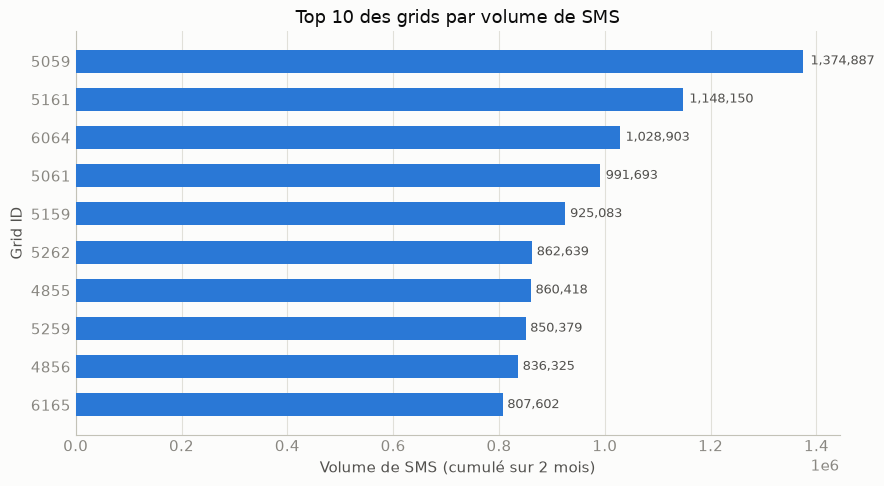

In [29]:
# Top 10 des grids par volume de SMS
data = smsGridActivity[:10]
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(data.index.astype(str), data['sms'], color=PALETTE['blue'], height=0.6, zorder=3)
ax.invert_yaxis()
for bar, value in zip(bars, data['sms']):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2, f"{value:,.0f}",
            va='center', ha='left', color=PALETTE['ink_secondary'], fontsize=9)
ax.set_xlabel("Volume de SMS (cumulé sur 2 mois)")
ax.set_ylabel("Grid ID")
ax.set_title("Top 10 des grids par volume de SMS")
style_axes(ax)
plt.tight_layout()
plt.show()

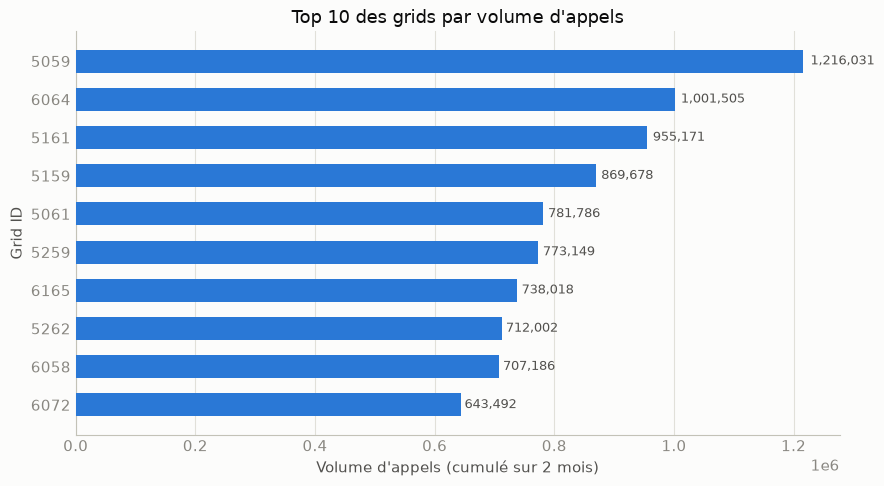

In [30]:
# Top 10 des grids par volume d'appels
data = callGridActivity[:10]
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(data.index.astype(str), data['call'], color=PALETTE['blue'], height=0.6, zorder=3)
ax.invert_yaxis()
for bar, value in zip(bars, data['call']):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2, f"{value:,.0f}",
            va='center', ha='left', color=PALETTE['ink_secondary'], fontsize=9)
ax.set_xlabel("Volume d'appels (cumulé sur 2 mois)")
ax.set_ylabel("Grid ID")
ax.set_title("Top 10 des grids par volume d'appels")
style_axes(ax)
plt.tight_layout()
plt.show()

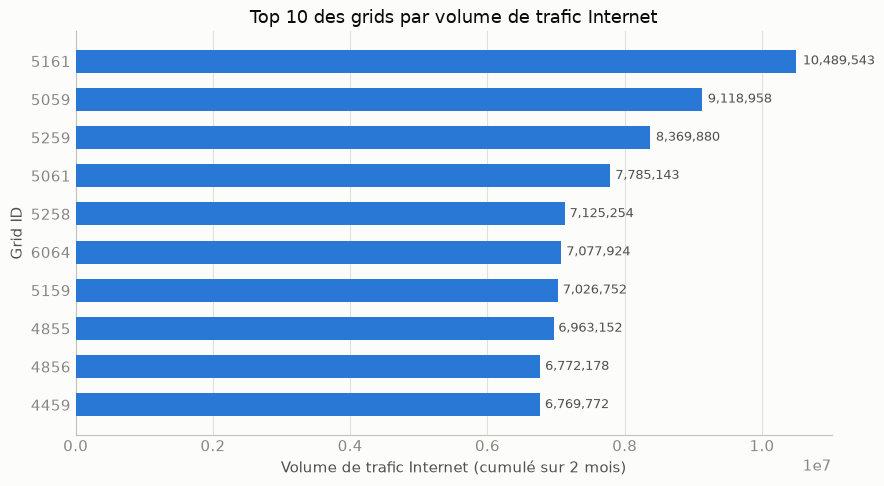

In [31]:
# Top 10 des grids par volume de trafic Internet
data = internetGridActivity[:10]
fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.barh(data.index.astype(str), data['internet'], color=PALETTE['blue'], height=0.6, zorder=3)
ax.invert_yaxis()
for bar, value in zip(bars, data['internet']):
    ax.text(bar.get_width() * 1.01, bar.get_y() + bar.get_height() / 2, f"{value:,.0f}",
            va='center', ha='left', color=PALETTE['ink_secondary'], fontsize=9)
ax.set_xlabel("Volume de trafic Internet (cumulé sur 2 mois)")
ax.set_ylabel("Grid ID")
ax.set_title("Top 10 des grids par volume de trafic Internet")
style_axes(ax)
plt.tight_layout()
plt.show()

In [32]:
# Charger les données de la grille
milan = gpd.read_file('Data/milano-grid.geojson')

# RAPPEL CRUCIAL : forcer la conversion en coordonnées GPS (WGS84)
milan = milan.to_crs(epsg=4326)

In [33]:
# Récupérer les identifiants uniques des grilles cibles
topgrids = pd.unique(top10.values.ravel())

# Filtrer le GeoDataFrame pour ne garder que ces 10 grilles
top_grids_gdf = milan.loc[milan['cellId'].isin(topgrids)]

In [34]:
# Extraire les limites de ces grilles spécifiques pour centrer la carte
min_lon, min_lat, max_lon, max_lat = top_grids_gdf.total_bounds

In [35]:
# Créer la carte Folium
m_top = folium.Map(
    location=[(min_lat + max_lat) / 2, (min_lon + max_lon) / 2],
    zoom_start=13,
    tiles="OpenStreetMap"
)

# Ajouter les grilles filtrées à la carte, mises en évidence dans la couleur catégorielle principale
folium.GeoJson(
    top_grids_gdf,
    style_function=lambda feature: {
        'fillColor': PALETTE['blue'],
        'color': PALETTE['blue'],
        'weight': 1.5,
        'fillOpacity': 0.45
    }
).add_to(m_top)

# Ajuster automatiquement le zoom sur cette zone précise
m_top.fit_bounds([[min_lat, min_lon], [max_lat, max_lon]])

# Afficher la carte directement dans le notebook
m_top

## Détection d'anomalies inspirée de DiNATrAX (signatures + distance d'édition)

Cette section adapte à notre dataset Milano l'approche du framework **DiNATrAX** (Maudoux & Boumerdassi, IEEE ICC 2024), qui détecte les anomalies réseau en combinant :

1. un **découpage temporel hiérarchique** (*Time Period, Slice & Slot*) ;
2. des **signatures numériques ("DNA")** qui encodent le comportement observé sous forme de séquence ;
3. une **distance d'édition (Damerau-Levenshtein)** pour quantifier l'écart entre une séquence observée et une séquence de référence ("normale").

### Adaptation à notre contexte

| Concept DiNATrAX | Adaptation Milano |
|---|---|
| Time Period | Type de jour (jour de la semaine, 0=lundi … 6=dimanche) |
| Slice | Une journée |
| Slot | Une heure (24 slots par jour, à partir de `hourlyGridActivity`) |
| Signature / DNA | Séquence de 24 lettres, une par heure, encodant le niveau de trafic Internet de cette grid sur cette heure |
| Séquence de référence | Séquence "consensus" (lettre majoritaire à chaque heure) calculée sur toutes les journées de même jour de semaine, pour une grid donnée |
| Distance d'édition | Distance de Damerau-Levenshtein entre la séquence observée d'une journée et la séquence de référence de sa grid/jour de semaine |
| Anomalie | Journée dont la distance à la référence est anormalement élevée par rapport aux autres journées de la même grid (z-score) |

On se concentre ici sur le canal **Internet** (le plus dense et le moins parcimonieux des 3 canaux) ; l'approche est directement extensible aux canaux SMS et appels en répétant le même pipeline sur `sms` / `call`.

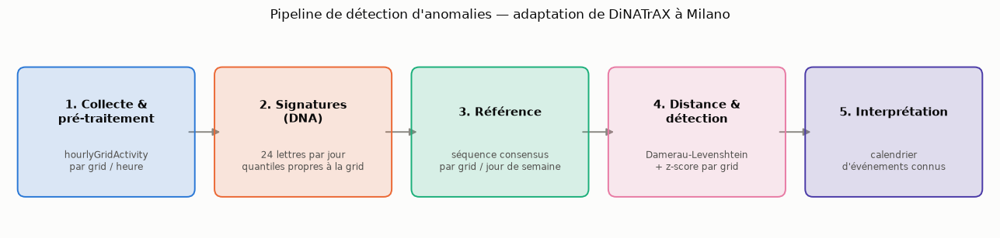

In [36]:
# Schéma du pipeline : les 5 étapes de l'adaptation DiNATrAX appliquées au dataset Milano
steps = [
    ("1. Collecte &\npré-traitement", "hourlyGridActivity\npar grid / heure", PALETTE['blue']),
    ("2. Signatures\n(DNA)", "24 lettres par jour\nquantiles propres à la grid", PALETTE['orange']),
    ("3. Référence", "séquence consensus\npar grid / jour de semaine", PALETTE['aqua']),
    ("4. Distance &\ndétection", "Damerau-Levenshtein\n+ z-score par grid", PALETTE['magenta']),
    ("5. Interprétation", "calendrier\nd'événements connus", PALETTE['violet']),
]

fig, ax = plt.subplots(figsize=(13, 3.2))
ax.set_xlim(0, len(steps))
ax.set_ylim(0, 1)
ax.axis('off')

box_w, box_h = 0.86, 0.62
for i, (title, subtitle, color) in enumerate(steps):
    x = i + (1 - box_w) / 2
    y = (1 - box_h) / 2
    ax.add_patch(FancyBboxPatch(
        (x, y), box_w, box_h, boxstyle="round,pad=0.02,rounding_size=0.04",
        linewidth=0, facecolor=color, alpha=0.16, zorder=2
    ))
    ax.add_patch(FancyBboxPatch(
        (x, y), box_w, box_h, boxstyle="round,pad=0.02,rounding_size=0.04",
        linewidth=1.4, edgecolor=color, facecolor='none', zorder=3
    ))
    ax.text(i + 0.5, y + box_h * 0.66, title, ha='center', va='center',
            fontsize=10.5, fontweight='bold', color=PALETTE['ink'], zorder=4)
    ax.text(i + 0.5, y + box_h * 0.26, subtitle, ha='center', va='center',
            fontsize=8.5, color=PALETTE['ink_secondary'], zorder=4)
    if i < len(steps) - 1:
        gap = (1 - box_w) / 2
        ax.add_patch(FancyArrowPatch(
            (i + 1 - gap - 0.02, 0.5), (i + 1 + gap + 0.02, 0.5),
            arrowstyle='-|>', mutation_scale=14, linewidth=1.4,
            color=PALETTE['ink_muted'], zorder=1
        ))

ax.set_title("Pipeline de détection d'anomalies — adaptation de DiNATrAX à Milano",
             fontsize=12, color=PALETTE['ink'], pad=14)
plt.tight_layout()
plt.show()

In [37]:
# Bibliothèque pour la distance d'édition de Damerau-Levenshtein (utilisée par DiNATrAX pour comparer les signatures)
from rapidfuzz.distance import DamerauLevenshtein

# Reconstruction de la matrice horaire : une ligne par (gridID, date), une colonne par heure (0 à 23)
hourly_reset = hourlyGridActivity.reset_index()[['gridID', 'startTime', 'internet']].copy()
hourly_reset['date'] = hourly_reset['startTime'].dt.normalize()
hourly_reset['hour'] = hourly_reset['startTime'].dt.hour

signature_matrix = hourly_reset.pivot_table(
    index=['gridID', 'date'], columns='hour', values='internet', aggfunc='sum'
)
# Les heures sans aucune activité n'apparaissent pas dans hourlyGridActivity : on les complète à 0
signature_matrix = signature_matrix.reindex(columns=range(24)).fillna(0.0)

signature_matrix.shape

(519953, 24)

### Encodage des signatures ("DNA")

Chaque grid a un niveau d'activité très différent des autres (voir le top 10 plus haut). Pour que les séquences restent comparables, on discrétise le trafic horaire **grid par grid** en niveaux (quantiles calculés sur l'historique complet de la grid), puis on associe une lettre à chaque niveau (A = trafic faible, F = trafic élevé). La signature d'une journée est la concaténation des 24 lettres, une par heure.

In [38]:
N_LEVELS = 6
ALPHABET = "ABCDEF"[:N_LEVELS]

def encode_levels(values, n_levels=N_LEVELS):
    """Discrétise les valeurs horaires d'une grid en `n_levels` quantiles propres à cette grid."""
    try:
        codes = pd.qcut(values, q=n_levels, labels=False, duplicates='drop')
    except ValueError:
        # Trafic constant (souvent 0) sur toute la période : une seule catégorie possible
        codes = pd.Series(0, index=values.index)
    return codes.fillna(0).astype(int)

# On encode chaque grid séparément : les seuils de quantiles sont propres à chaque grid,
# ce qui permet de comparer des grids très actives et des grids peu actives sur une même échelle relative
level_codes = (
    signature_matrix.stack()
    .groupby(level=0)  # groupby sur gridID
    .transform(encode_levels)
)

letters = level_codes.map(lambda c: ALPHABET[c])
letters_wide = letters.unstack('hour')
codes_wide = level_codes.unstack('hour')  # même matrice, en niveaux entiers (0..N_LEVELS-1) plutôt qu'en lettres

# Concaténation des 24 lettres, dans l'ordre des heures, pour former la signature de chaque (gridID, date)
hour_cols = sorted(letters_wide.columns)
letters_wide = letters_wide[hour_cols]
codes_wide = codes_wide[hour_cols]
dna_sequences = letters_wide[hour_cols[0]]
for h in hour_cols[1:]:
    dna_sequences = dna_sequences + letters_wide[h]
dna_sequences.name = 'dna'

dna_sequences.head(10)

gridID  date      
1       2013-11-01    CBAAAAABCDEEEEFFDEFEDCCC
        2013-11-02    BBAAAAABBDDDEDDDEEFFFFED
        2013-11-03    CBAAAAAABDDEEEFFEFFEEEDC
        2013-11-04    BBAAAAADCBBCCBCDDEEEFFED
        2013-11-05    CBBAAABCCCCCCCCCCDEFFFFD
        2013-11-06    CBAAAABCCBCBCCBBCDEEFEED
        2013-11-07    CBAAAAABCBBBBBDCCDDFFFED
        2013-11-08    BAAAAAACCCBBCCDDDEFEEFFD
        2013-11-09    CCBAAABBCDEDEFEFFFFFFFFE
        2013-11-10    CCBBAABBDEFEFFFFFFFFFFFE
Name: dna, dtype: str

### Séquence de référence et distance d'édition

Pour chaque grid, on construit une séquence "consensus" par jour de semaine : la lettre majoritaire observée à chaque heure parmi toutes les journées de ce jour de semaine (ex : tous les mardis de la grid 5059). C'est la séquence de référence, notre équivalent d'un "comportement normal".

On mesure ensuite l'écart de chaque journée réelle à sa référence via la **distance de Damerau-Levenshtein** entre les deux séquences de 24 lettres.

In [39]:
seq_df = dna_sequences.reset_index()
seq_df['weekday'] = seq_df['date'].dt.weekday  # 0 = lundi ... 6 = dimanche

# Calcul vectorisé (numpy) de la séquence consensus par (gridID, weekday) : pour chaque heure, on compte
# les occurrences de chaque niveau par groupe et on garde le plus fréquent. Une version basée sur des appels
# répétés à pandas.Series.mode() par groupe serait beaucoup trop lente sur ~520 000 lignes (des dizaines de minutes).
combined_key = seq_df['gridID'].to_numpy() * 10 + seq_df['weekday'].to_numpy()  # weekday tient sur 1 chiffre (0-6)
group_key, group_uniques = pd.factorize(combined_key)
n_groups = len(group_uniques)
codes_matrix = codes_wide.values  # (n_rows, 24), alignée sur le même ordre de lignes que seq_df

reference_codes = np.zeros((n_groups, len(hour_cols)), dtype=int)
for h in range(len(hour_cols)):
    counts = np.zeros((n_groups, N_LEVELS), dtype=int)
    np.add.at(counts, (group_key, codes_matrix[:, h]), 1)
    reference_codes[:, h] = counts.argmax(axis=1)

reference_by_group = {
    group_uniques[i]: ''.join(ALPHABET[c] for c in reference_codes[i])
    for i in range(n_groups)
}
seq_df['reference_dna'] = [reference_by_group[key] for key in combined_key]

# Distance de Damerau-Levenshtein entre la séquence observée et la séquence de référence de la grid/jour de semaine
seq_df['edit_distance'] = [
    DamerauLevenshtein.distance(dna, ref) for dna, ref in zip(seq_df['dna'], seq_df['reference_dna'])
]

seq_df.head(10)

,gridID,date,dna,weekday,reference_dna,edit_distance
0,1,2013-11-01,CBAAAAABCDEEEEFFDEFEDCCC,4,BBAAAABCCCBBCCCDDEFFFFFD,15
1,1,2013-11-02,BBAAAAABBDDDEDDDEEFFFFED,5,CBBAAAABCDEDEEEEEEEFFFED,8
2,1,2013-11-03,CBAAAAAABDDEEEFFEFFEEEDC,6,CCBAAAABBDEEFFFFEEFEFFED,10
3,1,2013-11-04,BBAAAAADCBBCCBCDDEEEFFED,0,BBAAAABCCBBBBCCDDDEFFEED,7
4,1,2013-11-05,CBBAAABCCCCCCCCCCDEFFFFD,1,CBBAAAACCCCBCCCCDDEFFFFE,4
5,1,2013-11-06,CBAAAABCCBCBCCBBCDEEFEED,2,CBAAAAABCBBBBCCDDDEEFFFD,8
6,1,2013-11-07,CBAAAAABCBBBBBDCCDDFFFED,3,CBAAAABBCBBBCCDCDDEFFFED,5
7,1,2013-11-08,BAAAAAACCCBBCCDDDEFEEFFD,4,BBAAAABCCCBBCCCDDEFFFFFD,5
8,1,2013-11-09,CCBAAABBCDEDEFEFFFFFFFFE,5,CBBAAAABCDEDEEEEEEEFFFED,9
9,1,2013-11-10,CCBBAABBDEFEFFFFFFFFFFFE,6,CCBAAAABBDEEFFFFEEFEFFED,8


### Détection des anomalies

Une distance élevée en valeur absolue ne veut pas dire grand-chose : certaines grids ont naturellement des journées plus variables que d'autres. On normalise donc `edit_distance` en z-score **par grid**, et on flague comme anomalie toute journée dont le z-score dépasse un seuil (3 par défaut, ajustable).

In [40]:
ANOMALY_THRESHOLD = 3.0  # en écarts-types au-dessus de la moyenne des distances de la grid

grid_stats = seq_df.groupby('gridID')['edit_distance'].agg(['mean', 'std']).rename(
    columns={'mean': 'grid_mean', 'std': 'grid_std'}
)
seq_df = seq_df.join(grid_stats, on='gridID')

# Les grids sans aucune variation (grid_std == 0, souvent des grids sans trafic) donnent un z-score NaN,
# donc automatiquement exclues du flag d'anomalie (NaN > seuil vaut False)
seq_df['z_score'] = (seq_df['edit_distance'] - seq_df['grid_mean']) / seq_df['grid_std']
seq_df['is_anomaly'] = seq_df['z_score'] > ANOMALY_THRESHOLD

print(f"Nombre de journées analysées : {len(seq_df):,}")
print(f"Nombre d'anomalies détectées : {seq_df['is_anomaly'].sum():,} "
      f"({seq_df['is_anomaly'].mean() * 100:.2f} % des journées)")

anomaly_results = seq_df[seq_df['is_anomaly']].sort_values('z_score', ascending=False)
anomaly_results[['gridID', 'date', 'weekday', 'dna', 'reference_dna', 'edit_distance', 'z_score']].head(20)

Nombre de journées analysées : 519,953
Nombre d'anomalies détectées : 772 (0.15 % des journées)


,gridID,date,weekday,dna,reference_dna,edit_distance,z_score
57459,1105,2014-01-01,2,FFECAAAAAABCCCCCCCDCCCCB,BBAAAABCDDFDFEEFEFEFDEDB,21,3.933516
168316,3237,2013-12-25,2,FFDCBBCCDEFFFFFFFFFFFFFF,CBAAAAABBABBBCCCCCDEEFED,23,3.913567
163064,3136,2013-12-25,2,FFDBBBCCDEEFFFFFFFFFFFFF,CBAAAAABBBBCBCCBCCDDEFEE,23,3.910439
224840,4324,2013-12-25,2,FECBBBBBBBDFFFFFFFFFFFDD,BBAAAABCDBCCCCFEEEEFEEDC,19,3.887347
46695,898,2014-01-01,2,CBBBAAAAAAAAAABBBCCCCBBB,BBAAAABCDDDDEEEEEEEDDCCC,20,3.883824
73891,1421,2014-01-01,2,CCCBBAAAAABBCCCCCCCCCCBB,BAAAAABCDDDDEDEEFFFEEDCC,21,3.862618
193803,3727,2014-01-01,2,CCBBAAAAAAABBBBBBBBBBBBB,BAAAAAACDDDEFFEFEEEEECCC,20,3.846476
497852,9575,2014-01-01,2,CCCCBBAAAABBBBCBCCCCCBBB,BAAAAACCDEEFEFFFFFEDDCCC,23,3.845008
397283,7641,2013-12-31,1,BAAAAAAAABBBBBBCCCEECBDB,CBBAAAABDFEEDDDDEDFFFFEC,20,3.842680
472060,9079,2014-01-01,2,CCBBAAAAAABBBBBBBCBCBBBB,BBBAAABCDDDDEEEEEFEDDCCC,20,3.828844


### Visualisation des résultats

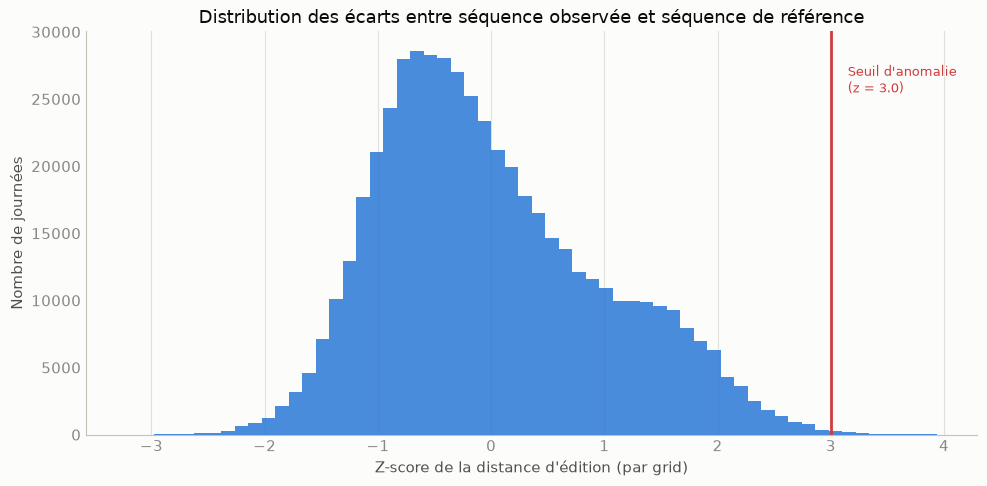

In [41]:
# Distribution des z-scores de distance, avec le seuil d'anomalie
values = seq_df['z_score'].dropna()

fig, ax = plt.subplots(figsize=(10, 5))
ax.hist(values, bins=60, color=PALETTE['blue'], alpha=0.85, zorder=3)
ax.axvline(ANOMALY_THRESHOLD, color=PALETTE['critical'], linewidth=2, zorder=4)
ax.text(ANOMALY_THRESHOLD + 0.15, ax.get_ylim()[1] * 0.92, f"Seuil d'anomalie\n(z = {ANOMALY_THRESHOLD})",
        color=PALETTE['critical'], fontsize=9, va='top')

ax.set_xlabel("Z-score de la distance d'édition (par grid)")
ax.set_ylabel("Nombre de journées")
ax.set_title("Distribution des écarts entre séquence observée et séquence de référence")
style_axes(ax)
plt.tight_layout()
plt.show()

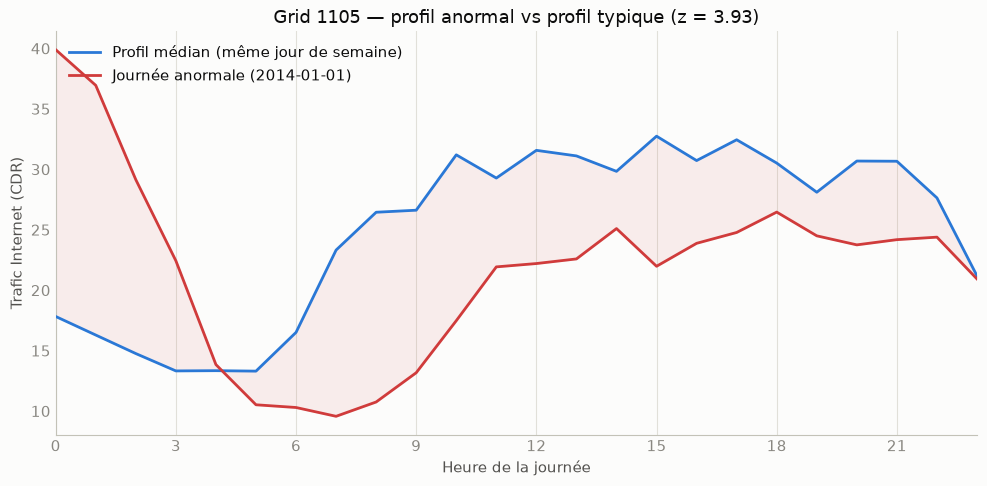

In [42]:
# Zoom sur l'anomalie la plus marquée : comparaison du profil horaire réel avec le profil médian
# des journées de même jour de semaine pour la même grid
example = anomaly_results.iloc[0]
ex_grid, ex_date, ex_weekday = example['gridID'], example['date'], example['weekday']

actual_profile = signature_matrix.loc[(ex_grid, ex_date)]

typical_dates = seq_df.loc[(seq_df['gridID'] == ex_grid) & (seq_df['weekday'] == ex_weekday), 'date']
typical_profile = signature_matrix.loc[[(ex_grid, d) for d in typical_dates]].median()

fig, ax = plt.subplots(figsize=(10, 5))
hours = range(24)
ax.plot(hours, typical_profile.values, color=PALETTE['blue'], linewidth=2,
        label="Profil médian (même jour de semaine)", zorder=3)
ax.plot(hours, actual_profile.values, color=PALETTE['critical'], linewidth=2,
        label=f"Journée anormale ({ex_date.date()})", zorder=4)
ax.fill_between(hours, typical_profile.values, actual_profile.values,
                 color=PALETTE['critical'], alpha=0.08, zorder=2)

ax.set_xlim(0, 23)
ax.set_xticks(range(0, 24, 3))
ax.set_xlabel("Heure de la journée")
ax.set_ylabel("Trafic Internet (CDR)")
ax.set_title(f"Grid {ex_grid} — profil anormal vs profil typique (z = {example['z_score']:.2f})")
ax.legend(loc='upper left', frameon=False)
style_axes(ax)
plt.tight_layout()
plt.show()

In [43]:
# Carte des grids en anomalie pour la journée qui en concentre le plus
worst_date = anomaly_results['date'].value_counts().idxmax()
anomalous_grids_that_day = anomaly_results.loc[anomaly_results['date'] == worst_date, 'gridID'].tolist()
print(f"Journée avec le plus d'anomalies : {worst_date.date()} ({len(anomalous_grids_that_day)} grids concernées)")

anomaly_gdf = milan.loc[milan['cellId'].isin(anomalous_grids_that_day)]

min_lon, min_lat, max_lon, max_lat = milan.total_bounds
m_anomaly = folium.Map(
    location=[(min_lat + max_lat) / 2, (min_lon + max_lon) / 2],
    zoom_start=11,
    tiles="OpenStreetMap"
)

folium.GeoJson(
    milan,
    style_function=lambda feature: {
        'fillColor': 'transparent', 'color': PALETTE['ink_secondary'], 'weight': 0.5, 'fillOpacity': 0
    }
).add_to(m_anomaly)

folium.GeoJson(
    anomaly_gdf,
    style_function=lambda feature: {
        'fillColor': PALETTE['critical'], 'color': PALETTE['critical'], 'weight': 1, 'fillOpacity': 0.55
    }
).add_to(m_anomaly)

m_anomaly

Journée avec le plus d'anomalies : 2014-01-01 (438 grids concernées)


### Interprétation : les anomalies correspondent-elles à des événements connus ?

Les exemples vus plus haut (1er janvier, 24-25 décembre) suggèrent que beaucoup d'anomalies détectées ne sont pas des dysfonctionnements, mais des **jours fériés ou événements calendaires** où le comportement de la population change légitimement (moins de trafic professionnel, plus de trafic personnel, etc.).

On construit un petit calendrier de repère (jours fériés italiens + quelques dates commerciales notables) sur la période étudiée, et on le confronte aux journées flaguées comme anormales. Cela permet de distinguer :

- les anomalies **expliquées** par un événement connu (pas un dysfonctionnement réseau, juste un changement d'usage attendu) ;
- les anomalies **résiduelles**, sans explication calendaire évidente — celles qui méritent une investigation plus poussée (panne, incident, comportement suspect).

⚠️ La période du **11 au 20 décembre 2013** est absente du dataset (fichiers manquants) : ce n'est pas un événement, mais un trou de données à garder en tête pour ne pas le confondre avec une anomalie.

In [44]:
# Calendrier de repère : jours fériés italiens, dates commerciales notables, et matchs de foot
# joués à San Siro (domicile Milan AC ou Inter) sur la période étudiée. Milan et Inter partagent
# le même stade : un "match à domicile" pour l'un des deux clubs veut dire une activité au stade.
# NB : les matchs du 11/12 (Milan-Ajax) et du 16/12 (Milan-Roma) tombent dans le trou de données
# du 11 au 20 décembre (fichiers manquants) — ils sont listés pour la complétude du calendrier,
# mais ne pourront jamais être rapprochés d'une anomalie faute de données ce jour-là.
KNOWN_EVENTS = {
    "2013-11-01": "Ognissanti (Toussaint, jour férié)",
    "2013-11-02": "Milan - Fiorentina (Serie A, San Siro)",
    "2013-11-09": "Inter - Livorno (Serie A, San Siro)",
    "2013-11-23": "Milan - Genoa (Serie A, San Siro)",
    "2013-11-29": "Black Friday",
    "2013-12-01": "Inter - Sampdoria (Serie A, San Siro)",
    "2013-12-04": "Inter - Trapani (Coppa Italia, San Siro)",
    "2013-12-07": "Sant'Ambrogio (jour férié local à Milan, patron de la ville)",
    "2013-12-08": "Immacolata Concezione (jour férié) + Inter - Parma (Serie A, San Siro)",
    "2013-12-11": "Milan - Ajax (Champions League, San Siro) — dans le trou de données",
    "2013-12-16": "Milan - Roma (Serie A, San Siro) — dans le trou de données",
    "2013-12-22": "Derby Milan - Inter (Serie A, San Siro)",
    "2013-12-24": "Vigile de Noël",
    "2013-12-25": "Noël (jour férié)",
    "2013-12-26": "Santo Stefano (jour férié)",
    "2013-12-31": "Saint-Sylvestre",
    "2014-01-01": "Nouvel An (jour férié)",
}
events_calendar = pd.Series(KNOWN_EVENTS)
events_calendar.index = pd.to_datetime(events_calendar.index)
events_calendar.name = 'event'

# Nombre de grids en anomalie, par date
daily_anomaly_counts = anomaly_results.groupby('date').size().rename('nb_grids_anormales')

daily_summary = daily_anomaly_counts.to_frame().join(events_calendar, how='left')
daily_summary['event'] = daily_summary['event'].fillna('— (sans explication calendaire)')
daily_summary = daily_summary.sort_values('nb_grids_anormales', ascending=False)

matched = anomaly_results['date'].isin(events_calendar.index)
print(f"{matched.sum()} anomalies sur {len(anomaly_results)} "
      f"({matched.mean() * 100:.1f} %) tombent un jour du calendrier de repère.")

daily_summary

712 anomalies sur 772 (92.2 %) tombent un jour du calendrier de repère.


,nb_grids_anormales,event
date,,
2014-01-01,438,Nouvel An (jour férié)
2013-12-25,113,Noël (jour férié)
2013-12-26,52,Santo Stefano (jour férié)
2013-12-07,36,"Sant'Ambrogio (jour férié local à Milan, patro..."
2013-12-08,20,Immacolata Concezione (jour férié) + Inter - P...
2013-12-31,19,Saint-Sylvestre
2013-12-28,14,— (sans explication calendaire)
2013-11-01,13,"Ognissanti (Toussaint, jour férié)"
2013-12-24,11,Vigile de Noël


C:\Users\ronic\AppData\Local\Temp\ipykernel_29520\302082184.py:23: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator. Otherwise, ticks may be mislabeled.
  ax.set_xticklabels(plot_summary.index.astype(str), rotation=90)


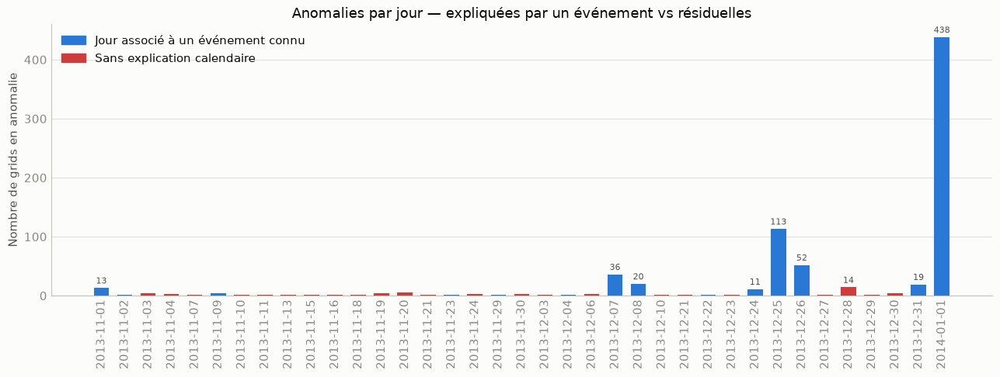

In [45]:
# Nombre de grids en anomalie par date, en distinguant les jours expliqués par un événement connu
plot_summary = daily_summary.sort_index()
is_known = plot_summary['event'] != '— (sans explication calendaire)'
colors = [PALETTE['blue'] if k else PALETTE['critical'] for k in is_known]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(plot_summary.index.astype(str), plot_summary['nb_grids_anormales'],
               color=colors, width=0.65, zorder=3)

for bar, value in zip(bars, plot_summary['nb_grids_anormales']):
    if value >= 10:  # étiquette directe uniquement sur les barres significatives
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 4, f"{value}",
                ha='center', va='bottom', fontsize=8, color=PALETTE['ink_secondary'])

ax.legend(
    handles=[
        mpatches.Patch(color=PALETTE['blue'], label='Jour associé à un événement connu'),
        mpatches.Patch(color=PALETTE['critical'], label='Sans explication calendaire'),
    ],
    loc='upper left', frameon=False,
)

ax.set_xticklabels(plot_summary.index.astype(str), rotation=90)
ax.set_ylabel("Nombre de grids en anomalie")
ax.set_title("Anomalies par jour — expliquées par un événement vs résiduelles")
style_axes(ax, grid_axis='y')
plt.tight_layout()
plt.show()

## Export des données pour la visualisation 3D (deck.gl)

On exporte ici tout ce qu'il faut pour une visualisation interactive en dehors du notebook :
le fond de carte (grille de Milan reprojetée en WGS84), le trafic Internet heure par heure
pour chaque grid, et le flag d'anomalie par grid/jour. Le format est volontairement compact
(tableaux binaires plutôt que JSON) car on exporte ~130 millions de valeurs (52 jours × 24
heures × 10 000 grids).

In [46]:
import os
os.makedirs('viz', exist_ok=True)

# Fond de carte : la grille de Milan, reprojetée en WGS84 (lon/lat) — indispensable pour deck.gl
milan.to_file('viz/milano-grid-wgs84.geojson', driver='GeoJSON')

# L'ordre des grids dans le geojson fixe l'ordre utilisé pour indexer les tableaux binaires ci-dessous
grid_order = milan['cellId'].tolist()
n_grids = len(grid_order)
grid_index = {g: i for i, g in enumerate(grid_order)}

print(f"{n_grids} grids exportées vers viz/milano-grid-wgs84.geojson")

10000 grids exportées vers viz/milano-grid-wgs84.geojson


In [47]:
# Ordre chronologique des jours disponibles (52 jours réels, le trou du 11-20 déc. n'y figure pas)
dates_sorted = sorted(signature_matrix.index.get_level_values('date').unique())
n_days = len(dates_sorted)
date_index = {d: i for i, d in enumerate(dates_sorted)}
n_hours = 24

# Tableau plat (jour, heure, grid) -> trafic Internet, initialisé à 0 (pas d'activité par défaut)
traffic = np.zeros((n_days, n_hours, n_grids), dtype=np.float32)

sm_reset = signature_matrix.reset_index()
gi_arr = sm_reset['gridID'].map(grid_index).to_numpy()
di_arr = sm_reset['date'].map(date_index).to_numpy()
values_arr = sm_reset[hour_cols].to_numpy()  # (n_lignes, 24)

for h in range(n_hours):
    traffic[di_arr, h, gi_arr] = values_arr[:, h]

# Encodage compact : x10 arrondi à l'entier le plus proche, stocké en Uint16 (2 octets au lieu de 4)
# pour diviser par 2 la taille du fichier tout en gardant une décimale de précision
traffic_u16 = np.clip(np.round(traffic * 10), 0, 65535).astype(np.uint16)
traffic_u16.tofile('viz/traffic.bin')

print(f"traffic.bin : {traffic_u16.nbytes / 1e6:.1f} Mo — forme (jours={n_days}, heures={n_hours}, grids={n_grids})")

traffic.bin : 25.0 Mo — forme (jours=52, heures=24, grids=10000)


In [48]:
import json

# Tableau plat (jour, grid) -> 0/1 anomalie détectée ce jour-là pour cette grid
anomaly = np.zeros((n_days, n_grids), dtype=np.uint8)

anomalous = seq_df[seq_df['is_anomaly']]
gi_arr2 = anomalous['gridID'].map(grid_index).to_numpy()
di_arr2 = anomalous['date'].map(date_index).to_numpy()
anomaly[di_arr2, gi_arr2] = 1

anomaly.tofile('viz/anomaly.bin')

# Métadonnées : dates dans l'ordre, gridIDs dans l'ordre (pour aligner le geojson avec les tableaux binaires)
meta = {
    'dates': [d.strftime('%Y-%m-%d') for d in dates_sorted],
    'gridIds': grid_order,
    'nDays': n_days,
    'nHours': n_hours,
    'nGrids': n_grids,
    'maxValue': float(traffic_u16.max()),
}
with open('viz/meta.json', 'w', encoding='utf-8') as f:
    json.dump(meta, f)

print(f"anomaly.bin : {anomaly.nbytes / 1e6:.2f} Mo — {anomaly.sum()} anomalies au total")
print(f"meta.json écrit — {n_days} jours, {n_grids} grids")

anomaly.bin : 0.52 Mo — 772 anomalies au total
meta.json écrit — 52 jours, 10000 grids
